# SAN Normalization Strategy Demo

This notebook demonstrates how SAN handles image normalization with:
1. Fixed target dimensions (1600×320)
2. Dynamic batching with aspect ratio preservation
3. Comparison of stroke-to-image conversion before and after normalization

Using file: `000f8519b50a9e65.inkml` (expression: v_i=C_i-V)

In [1]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from PIL import Image, ImageDraw
import torch

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Parse InkML and Extract Strokes

In [2]:
def parse_inkml(file_path):
    """
    Parse .inkml file and extract stroke data
    Returns: dict with label and strokes data
    """
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    # Extract namespace
    namespace = {'ink': 'http://www.w3.org/2003/InkML'}
    
    # Get label
    label_elem = root.find('.//ink:annotation[@type="label"]', namespace)
    label = label_elem.text if label_elem is not None else "Unknown"
    
    # Extract all traces (strokes)
    strokes = []
    traces = root.findall('.//ink:trace', namespace)
    
    for trace in traces:
        trace_id = trace.get('id')
        trace_data = trace.text.strip()
        
        # Parse points: "x y t,x y t,x y t"
        points = []
        for point_str in trace_data.split(','):
            coords = point_str.strip().split()
            if len(coords) >= 3:
                x, y, t = float(coords[0]), float(coords[1]), float(coords[2])
                points.append((x, y, t))
        
        strokes.append({
            'id': trace_id,
            'points': points
        })
    
    return {
        'label': label,
        'strokes': strokes
    }

# Parse the sample file
inkml_data = parse_inkml('000f8519b50a9e65.inkml')
print(f"Expression label: {inkml_data['label']}")
print(f"Number of strokes: {len(inkml_data['strokes'])}")

# Get coordinate bounds
all_x, all_y = [], []
for stroke in inkml_data['strokes']:
    for x, y, t in stroke['points']:
        all_x.append(x)
        all_y.append(y)

original_bounds = {
    'x_min': min(all_x), 'x_max': max(all_x),
    'y_min': min(all_y), 'y_max': max(all_y)
}
original_width = original_bounds['x_max'] - original_bounds['x_min']
original_height = original_bounds['y_max'] - original_bounds['y_min']
original_aspect_ratio = original_width / original_height

print(f"\nOriginal bounds:")
print(f"  X: [{original_bounds['x_min']:.1f}, {original_bounds['x_max']:.1f}] (width: {original_width:.1f})")
print(f"  Y: [{original_bounds['y_min']:.1f}, {original_bounds['y_max']:.1f}] (height: {original_height:.1f})")
print(f"  Aspect ratio: {original_aspect_ratio:.2f}")

Expression label: v_i=C_i-V
Number of strokes: 10

Original bounds:
  X: [16.5, 3219.6] (width: 3203.1)
  Y: [-447.8, 98.3] (height: 546.1)
  Aspect ratio: 5.87


## 2. Convert Strokes to Image

Original image size: 3303×646
Original scale factors: X=1.000, Y=1.000


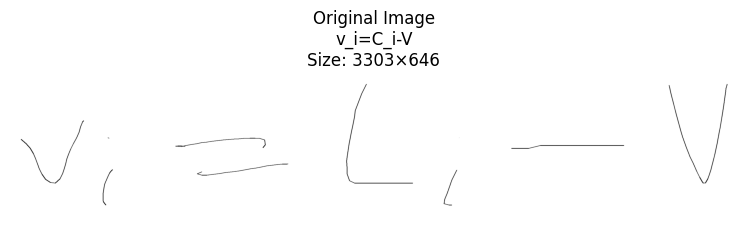

In [3]:
def strokes_to_image(inkml_data, target_size=None, background_color=255, stroke_color=0, stroke_width=3):
    """
    Convert stroke data to image representation
    Args:
        inkml_data: Parsed InkML data
        target_size: (width, height) for output image. If None, uses original bounds
        background_color: Background pixel value (255 = white)
        stroke_color: Stroke pixel value (0 = black)
        stroke_width: Width of strokes in pixels
    """
    # Get coordinate bounds
    all_x, all_y = [], []
    for stroke in inkml_data['strokes']:
        for x, y, t in stroke['points']:
            all_x.append(x)
            all_y.append(y)
    
    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)
    width = x_max - x_min
    height = y_max - y_min
    
    # Determine image size
    if target_size is None:
        # Use original proportions with some padding
        padding = 50
        img_width = int(width + 2 * padding)
        img_height = int(height + 2 * padding)
        x_offset = padding - x_min
        y_offset = padding - y_min
        scale_x = scale_y = 1.0
    else:
        target_width, target_height = target_size
        img_width, img_height = target_width, target_height
        
        # Calculate scale to fit within target while preserving aspect ratio
        scale_x = target_width / width
        scale_y = target_height / height
        scale = min(scale_x, scale_y)  # Preserve aspect ratio
        
        # Center the scaled image
        scaled_width = width * scale
        scaled_height = height * scale
        x_offset = (target_width - scaled_width) / 2 - x_min * scale
        y_offset = (target_height - scaled_height) / 2 - y_min * scale
        
        scale_x = scale_y = scale
    
    # Create PIL image for drawing
    img = Image.new('L', (img_width, img_height), background_color)
    draw = ImageDraw.Draw(img)
    
    # Draw each stroke
    for stroke in inkml_data['strokes']:
        if len(stroke['points']) > 1:
            # Convert points to image coordinates
            image_points = []
            for x, y, t in stroke['points']:
                img_x = x * scale_x + x_offset
                img_y = y * scale_y + y_offset
                image_points.append((img_x, img_y))
            
            # Draw stroke as connected lines
            for i in range(len(image_points) - 1):
                draw.line([image_points[i], image_points[i+1]], 
                         fill=stroke_color, width=stroke_width)
    
    # Convert to numpy array
    img_array = np.array(img)
    
    return img_array, {
        'original_bounds': (x_min, y_min, x_max, y_max),
        'image_size': (img_width, img_height),
        'scale': (scale_x, scale_y),
        'offset': (x_offset, y_offset)
    }

# Create original image (natural size)
original_image, original_info = strokes_to_image(inkml_data)
print(f"Original image size: {original_image.shape[1]}×{original_image.shape[0]}")
print(f"Original scale factors: X={original_info['scale'][0]:.3f}, Y={original_info['scale'][1]:.3f}")

# Display original image
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title(f"Original Image\n{inkml_data['label']}\nSize: {original_image.shape[1]}×{original_image.shape[0]}")
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. SAN's Fixed Dimension Normalization (1600×320)

SAN Target Dimensions: 1600×320
SAN Target Aspect Ratio: 5.00
Original Expression Aspect Ratio: 5.87

SAN Normalization Results:
  Image size: 1600×320
  Scale factor applied: 0.499519 (same for X and Y to preserve aspect ratio)
  Offset: X=-8.3, Y=247.3
  Actual content size: 1600.0×272.8
  Padding: Left/Right=-8.3, Top/Bottom=247.3


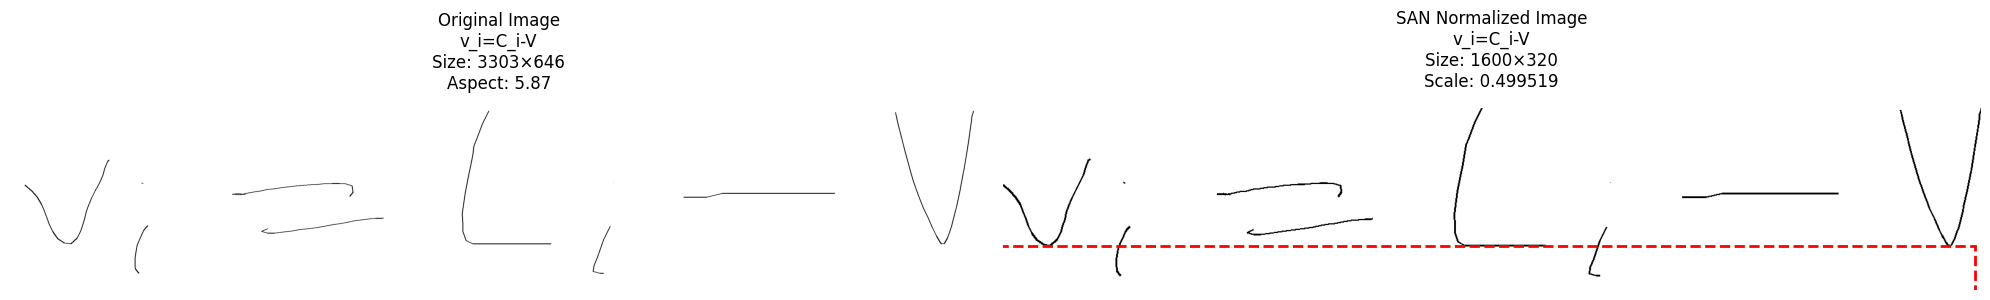

In [4]:
# SAN target dimensions from config.yaml
SAN_WIDTH = 1600
SAN_HEIGHT = 320
SAN_ASPECT_RATIO = SAN_WIDTH / SAN_HEIGHT

print(f"SAN Target Dimensions: {SAN_WIDTH}×{SAN_HEIGHT}")
print(f"SAN Target Aspect Ratio: {SAN_ASPECT_RATIO:.2f}")
print(f"Original Expression Aspect Ratio: {original_aspect_ratio:.2f}")

# Create SAN-normalized image
san_image, san_info = strokes_to_image(inkml_data, target_size=(SAN_WIDTH, SAN_HEIGHT))

print(f"\nSAN Normalization Results:")
print(f"  Image size: {san_image.shape[1]}×{san_image.shape[0]}")
print(f"  Scale factor applied: {san_info['scale'][0]:.6f} (same for X and Y to preserve aspect ratio)")
print(f"  Offset: X={san_info['offset'][0]:.1f}, Y={san_info['offset'][1]:.1f}")

# Calculate actual used area within SAN dimensions
scaled_width = original_width * san_info['scale'][0]
scaled_height = original_height * san_info['scale'][1]
print(f"  Actual content size: {scaled_width:.1f}×{scaled_height:.1f}")
print(f"  Padding: Left/Right={san_info['offset'][0]:.1f}, Top/Bottom={san_info['offset'][1]:.1f}")

# Side-by-side comparison
plt.figure(figsize=(20, 8))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title(f"Original Image\n{inkml_data['label']}\nSize: {original_image.shape[1]}×{original_image.shape[0]}\nAspect: {original_aspect_ratio:.2f}")
plt.axis('off')

# SAN normalized image
plt.subplot(1, 2, 2)
plt.imshow(san_image, cmap='gray')
plt.title(f"SAN Normalized Image\n{inkml_data['label']}\nSize: {SAN_WIDTH}×{SAN_HEIGHT}\nScale: {san_info['scale'][0]:.6f}")
plt.axis('off')

# Add content boundary rectangle to show actual used area
from matplotlib.patches import Rectangle
content_x = san_info['offset'][0]
content_y = san_info['offset'][1] 
rect = Rectangle((content_x, content_y), scaled_width, scaled_height, 
                linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
plt.gca().add_patch(rect)

plt.tight_layout()
plt.show()

## 4. Simulate Dynamic Batching with Different Expression Lengths

In [5]:
def simulate_expressions(base_expression, expression_configs):
    """
    Simulate different expression lengths by scaling the base expression
    """
    expressions = []
    
    for config in expression_configs:
        name = config['name']
        width_scale = config['width_scale']
        label = config['label']
        
        # Create scaled version of strokes
        scaled_strokes = []
        for stroke in base_expression['strokes']:
            scaled_points = []
            for x, y, t in stroke['points']:
                # Scale X coordinate to simulate longer/shorter expressions
                scaled_x = x * width_scale
                scaled_points.append((scaled_x, y, t))
            
            scaled_strokes.append({
                'id': stroke['id'],
                'points': scaled_points
            })
        
        expressions.append({
            'name': name,
            'label': label,
            'strokes': scaled_strokes,
            'width_scale': width_scale
        })
    
    return expressions

# Create simulated expressions of different lengths
expression_configs = [
    {'name': 'short', 'width_scale': 0.3, 'label': 'y = a'},
    {'name': 'medium', 'width_scale': 1.0, 'label': 'v_i = C_i - V'},  # Original
    {'name': 'long', 'width_scale': 2.5, 'label': 'x = ax + b - 30 + z'}
]

simulated_expressions = simulate_expressions(inkml_data, expression_configs)

print("Simulated Expressions:")
for expr in simulated_expressions:
    # Calculate bounds
    all_x, all_y = [], []
    for stroke in expr['strokes']:
        for x, y, t in stroke['points']:
            all_x.append(x)
            all_y.append(y)
    
    width = max(all_x) - min(all_x)
    height = max(all_y) - min(all_y)
    aspect = width / height
    
    print(f"  {expr['name']:6s}: {expr['label']:20s} | Width: {width:6.1f} | Aspect: {aspect:.2f}")

Simulated Expressions:
  short : y = a                | Width:  960.9 | Aspect: 1.76
  medium: v_i = C_i - V        | Width: 3203.1 | Aspect: 5.87
  long  : x = ax + b - 30 + z  | Width: 8007.7 | Aspect: 14.66


## 5. Apply SAN Normalization to All Expression Lengths

In [6]:
# Process all expressions with SAN normalization
normalized_results = []

for expr in simulated_expressions:
    # Convert to image with SAN dimensions
    san_img, san_info = strokes_to_image(expr, target_size=(SAN_WIDTH, SAN_HEIGHT))
    
    # Calculate statistics
    all_x, all_y = [], []
    for stroke in expr['strokes']:
        for x, y, t in stroke['points']:
            all_x.append(x)
            all_y.append(y)
    
    orig_width = max(all_x) - min(all_x)
    orig_height = max(all_y) - min(all_y)
    scale_factor = san_info['scale'][0]
    
    # Estimate character size in normalized image
    # Assume ~5 characters per expression for rough estimate
    char_size_pixels = (orig_width * scale_factor) / 5
    char_size_normalized = char_size_pixels / SAN_WIDTH
    
    normalized_results.append({
        'expression': expr,
        'image': san_img,
        'info': san_info,
        'original_width': orig_width,
        'scale_factor': scale_factor,
        'char_size_pixels': char_size_pixels,
        'char_size_normalized': char_size_normalized
    })

# Display normalization results
print("SAN Normalization Analysis:")
print("-" * 80)
print(f"{'Expression':<20} {'Orig Width':<12} {'Scale Factor':<14} {'Char Size (px)':<15} {'Char Size (norm)':<15}")
print("-" * 80)

for result in normalized_results:
    expr = result['expression']
    print(f"{expr['label']:<20} {result['original_width']:8.1f}     {result['scale_factor']:10.6f}     {result['char_size_pixels']:10.1f}      {result['char_size_normalized']:12.6f}")

print("-" * 80)
print("Key Observations:")
print(f"• Short expressions get LARGER scale factors → characters appear BIGGER")
print(f"• Long expressions get SMALLER scale factors → characters appear SMALLER")
print(f"• Character size varies by {normalized_results[0]['char_size_normalized']/normalized_results[-1]['char_size_normalized']:.1f}× between shortest and longest")

SAN Normalization Analysis:
--------------------------------------------------------------------------------
Expression           Orig Width   Scale Factor   Char Size (px)  Char Size (norm)
--------------------------------------------------------------------------------
y = a                   960.9       0.585941          112.6          0.070381
v_i = C_i - V          3203.1       0.499519          320.0          0.200000
x = ax + b - 30 + z    8007.7       0.199808          320.0          0.200000
--------------------------------------------------------------------------------
Key Observations:
• Short expressions get LARGER scale factors → characters appear BIGGER
• Long expressions get SMALLER scale factors → characters appear SMALLER
• Character size varies by 0.4× between shortest and longest


## 6. Visual Comparison of All Normalized Expressions

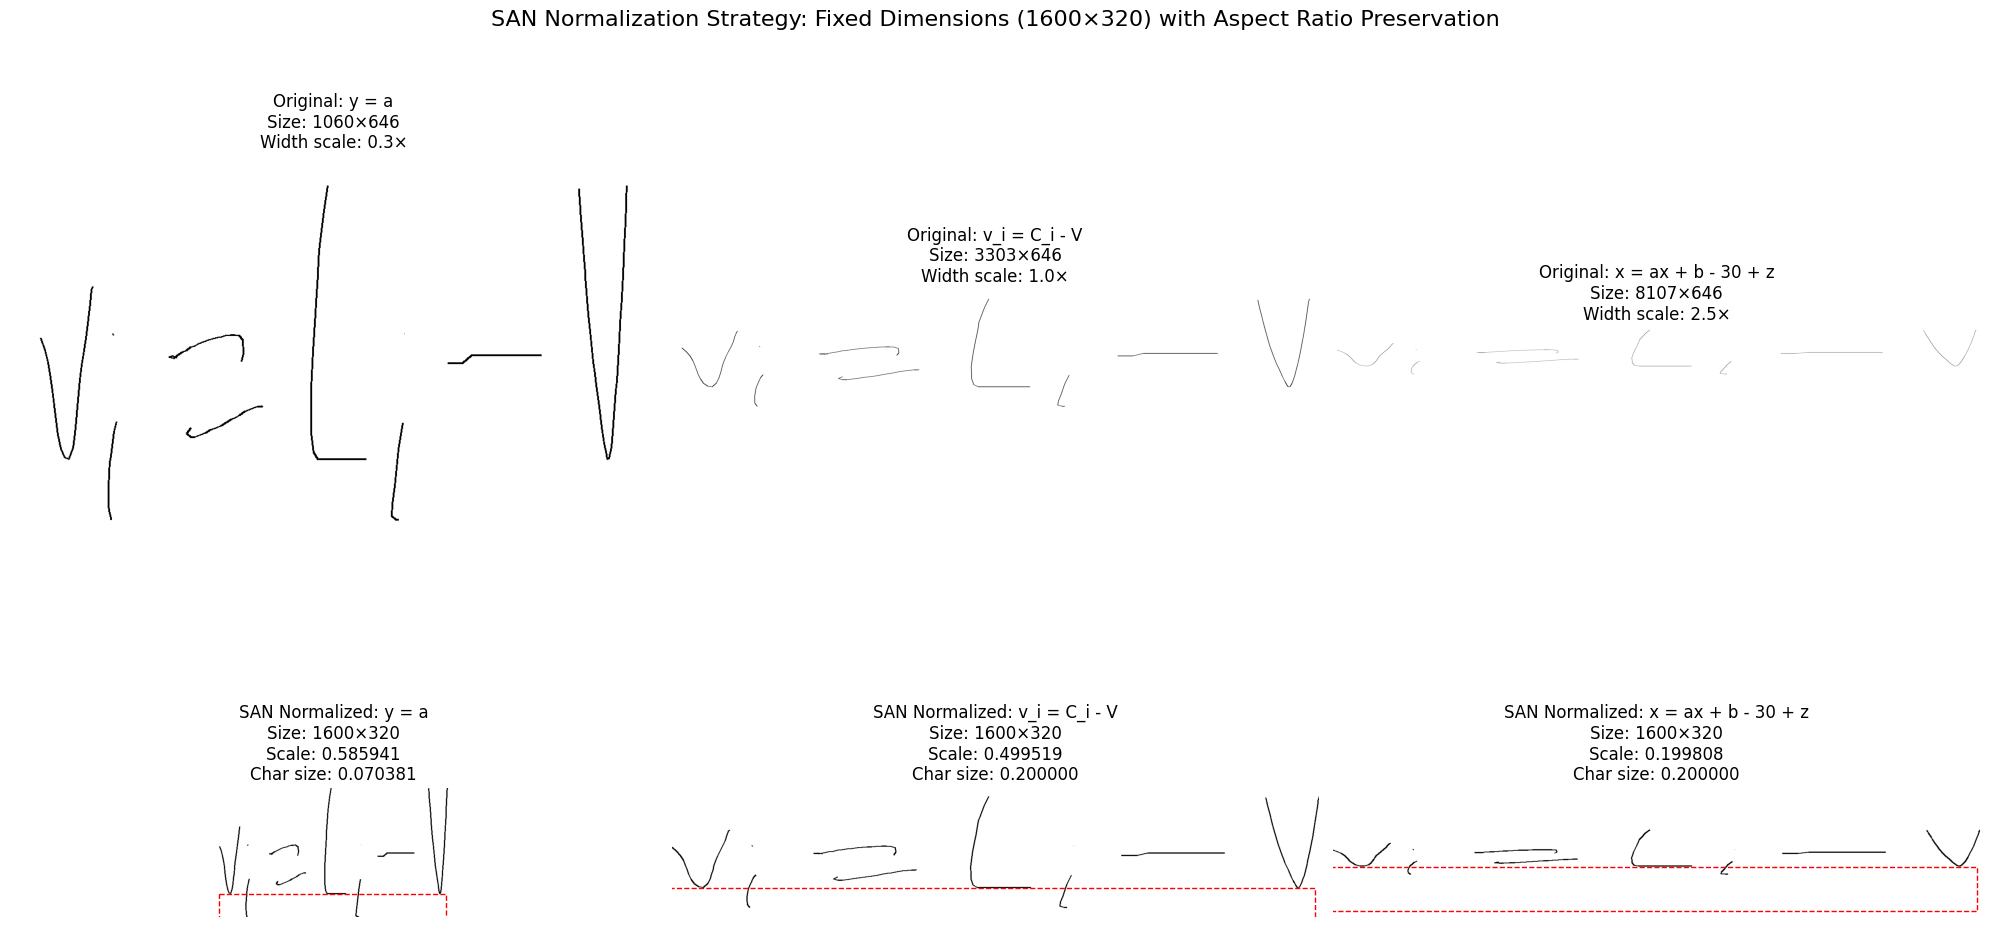

In [7]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Top row: Original proportions
for i, result in enumerate(normalized_results):
    expr = result['expression']
    orig_img, orig_info = strokes_to_image(expr)  # Original proportions
    
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Original: {expr['label']}\nSize: {orig_img.shape[1]}×{orig_img.shape[0]}\nWidth scale: {expr['width_scale']:.1f}×")
    axes[0, i].axis('off')

# Bottom row: SAN normalized (1600×320)
for i, result in enumerate(normalized_results):
    expr = result['expression']
    san_img = result['image']
    scale = result['scale_factor']
    char_size = result['char_size_normalized']
    
    axes[1, i].imshow(san_img, cmap='gray')
    axes[1, i].set_title(f"SAN Normalized: {expr['label']}\nSize: {SAN_WIDTH}×{SAN_HEIGHT}\nScale: {scale:.6f}\nChar size: {char_size:.6f}")
    axes[1, i].axis('off')
    
    # Add red dashed rectangle to show content area
    content_x = result['info']['offset'][0]
    content_y = result['info']['offset'][1]
    content_w = result['original_width'] * scale
    content_h = (max([max([y for x,y,t in stroke['points']]) for stroke in expr['strokes']]) - 
                 min([min([y for x,y,t in stroke['points']]) for stroke in expr['strokes']])) * scale
    
    rect = Rectangle((content_x, content_y), content_w, content_h,
                    linewidth=1, edgecolor='red', facecolor='none', linestyle='--')
    axes[1, i].add_patch(rect)

plt.suptitle('SAN Normalization Strategy: Fixed Dimensions (1600×320) with Aspect Ratio Preservation', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Demonstrate Batch Processing with Masks

Batch Processing Simulation:
Batch max content dimensions: 1600.0 × 100.0
All images padded to: 1600 × 320 (SAN fixed size)



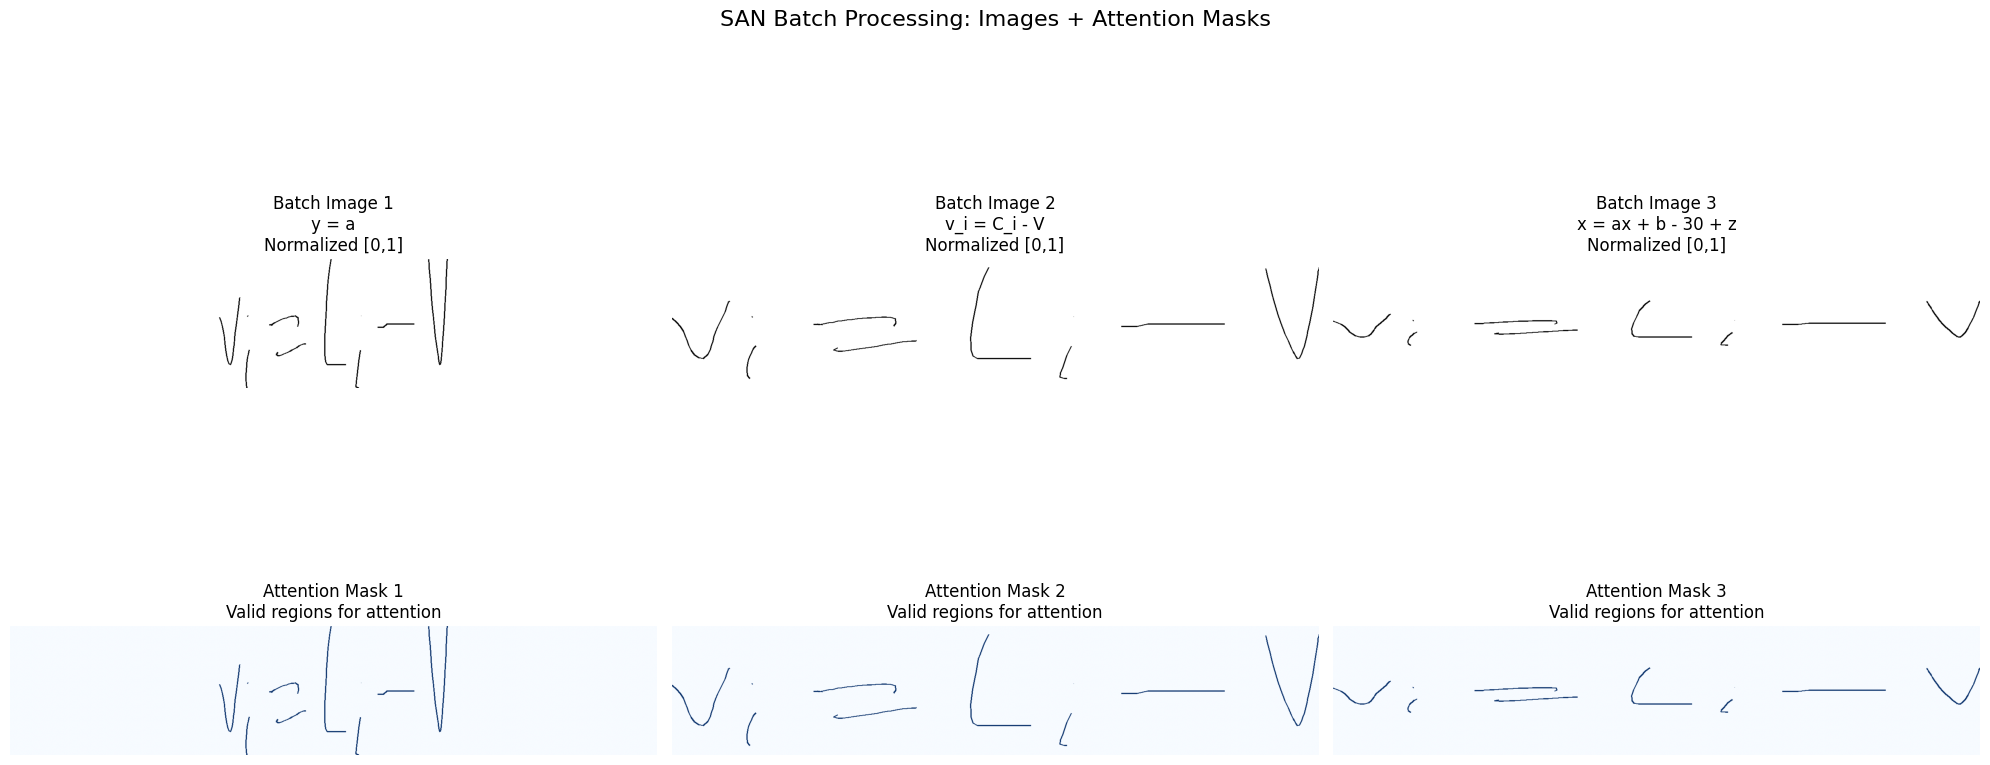


Batch Statistics:
  y = a               :   4667/512000 pixels (  0.9% coverage)
  v_i = C_i - V       :   5536/512000 pixels (  1.1% coverage)
  x = ax + b - 30 + z :   4136/512000 pixels (  0.8% coverage)


In [8]:
def simulate_san_batch_processing(normalized_results):
    """
    Simulate SAN's batch processing with dynamic sizing and masks
    """
    # In real SAN: batch finds max dimensions across all images in batch
    # Here we simulate by finding max content dimensions
    
    max_content_width = 0
    max_content_height = 0
    
    batch_info = []
    
    for result in normalized_results:
        # Calculate actual content size within the 1600×320 canvas
        content_w = result['original_width'] * result['scale_factor']
        content_h = 100  # Approximate height after scaling
        
        max_content_width = max(max_content_width, content_w)
        max_content_height = max(max_content_height, content_h)
        
        batch_info.append({
            'expression': result['expression']['label'],
            'content_width': content_w,
            'content_height': content_h,
            'image': result['image']
        })
    
    print("Batch Processing Simulation:")
    print(f"Batch max content dimensions: {max_content_width:.1f} × {max_content_height:.1f}")
    print(f"All images padded to: {SAN_WIDTH} × {SAN_HEIGHT} (SAN fixed size)")
    print()
    
    # Create batch tensor (simulating dataset.py:74-92)
    batch_size = len(batch_info)
    batch_images = np.zeros((batch_size, SAN_HEIGHT, SAN_WIDTH), dtype=np.float32)
    batch_masks = np.zeros((batch_size, SAN_HEIGHT, SAN_WIDTH), dtype=np.float32)
    
    for i, info in enumerate(batch_info):
        # Normalize pixel values (dataset.py:33)
        img = info['image'].astype(np.float32) / 255.0
        batch_images[i] = img
        
        # Create mask for valid regions (dataset.py:83)
        mask = (img < 0.9).astype(np.float32)  # Non-background regions
        batch_masks[i] = mask
    
    return batch_images, batch_masks, batch_info

# Simulate batch processing
batch_images, batch_masks, batch_info = simulate_san_batch_processing(normalized_results)

# Visualize batch with masks
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i in range(3):
    # Top row: Normalized images
    axes[0, i].imshow(batch_images[i], cmap='gray')
    axes[0, i].set_title(f"Batch Image {i+1}\n{batch_info[i]['expression']}\nNormalized [0,1]")
    axes[0, i].axis('off')
    
    # Bottom row: Attention masks
    axes[1, i].imshow(batch_masks[i], cmap='Blues')
    axes[1, i].set_title(f"Attention Mask {i+1}\nValid regions for attention")
    axes[1, i].axis('off')

plt.suptitle('SAN Batch Processing: Images + Attention Masks', fontsize=16)
plt.tight_layout()
plt.show()

print("\nBatch Statistics:")
for i, info in enumerate(batch_info):
    valid_pixels = batch_masks[i].sum()
    total_pixels = batch_masks[i].size
    coverage = valid_pixels / total_pixels * 100
    print(f"  {info['expression']:<20}: {valid_pixels:6.0f}/{total_pixels} pixels ({coverage:5.1f}% coverage)")

## 8. Key Findings Summary

In [9]:
print("="*80)
print("SAN NORMALIZATION STRATEGY ANALYSIS")
print("="*80)
print()
print("🎯 FIXED TARGET DIMENSIONS:")
print(f"   • All expressions normalized to {SAN_WIDTH}×{SAN_HEIGHT} pixels")
print(f"   • Target aspect ratio: {SAN_ASPECT_RATIO:.1f}:1 (optimized for math expressions)")
print()
print("📏 ASPECT RATIO PRESERVATION:")
print(f"   • Original expression aspect ratios are preserved")
print(f"   • Unused space filled with padding (white pixels)")
print(f"   • Content centered within target dimensions")
print()
print("⚖️  CHARACTER SIZE VARIATION ISSUE:")

# Calculate character size variation
char_sizes = [r['char_size_normalized'] for r in normalized_results]
min_char = min(char_sizes)
max_char = max(char_sizes)
size_ratio = max_char / min_char

print(f"   • Short expressions: Character size ≈ {max_char:.6f} (normalized)")
print(f"   • Long expressions:  Character size ≈ {min_char:.6f} (normalized)")
print(f"   • Size variation ratio: {size_ratio:.1f}×")
print(f"   • This means characters appear {size_ratio:.1f}× larger in short vs long expressions!")
print()
print("🧠 NEURAL NETWORK IMPLICATIONS:")
print(f"   • DenseNet encoder must learn scale-invariant features")
print(f"   • Attention mechanism helps focus on relevant regions")
print(f"   • Training requires diverse expression lengths for robustness")
print(f"   • Attention masks prevent network from attending to padding")
print()
print("📦 BATCH PROCESSING BENEFITS:")
print(f"   • Fixed dimensions enable efficient GPU batching")
print(f"   • Dynamic masking handles variable content sizes")
print(f"   • Padding ignored during attention computation")
print()
print("⚠️  REMAINING CHALLENGES:")
print(f"   • Scale variation remains a fundamental issue")
print(f"   • Network must generalize across {size_ratio:.1f}× character size differences")
print(f"   • Very long expressions may be heavily downscaled")
print(f"   • Very short expressions may have excessive padding")
print("="*80)

SAN NORMALIZATION STRATEGY ANALYSIS

🎯 FIXED TARGET DIMENSIONS:
   • All expressions normalized to 1600×320 pixels
   • Target aspect ratio: 5.0:1 (optimized for math expressions)

📏 ASPECT RATIO PRESERVATION:
   • Original expression aspect ratios are preserved
   • Unused space filled with padding (white pixels)
   • Content centered within target dimensions

⚖️  CHARACTER SIZE VARIATION ISSUE:
   • Short expressions: Character size ≈ 0.200000 (normalized)
   • Long expressions:  Character size ≈ 0.070381 (normalized)
   • Size variation ratio: 2.8×
   • This means characters appear 2.8× larger in short vs long expressions!

🧠 NEURAL NETWORK IMPLICATIONS:
   • DenseNet encoder must learn scale-invariant features
   • Attention mechanism helps focus on relevant regions
   • Training requires diverse expression lengths for robustness
   • Attention masks prevent network from attending to padding

📦 BATCH PROCESSING BENEFITS:
   • Fixed dimensions enable efficient GPU batching
   • Dyna